Importing useful modules and packages

In [168]:
import numpy as np
import random,math
import matplotlib as mpl
import matplotlib.pyplot as plt


Read and open the cvs file, that exist within the directory

In [169]:
file_path = r"C:\Users\abdir\Data-sciene\Coding-projects\Datasets\CVS_files-ISLP\College.csv"
College_info = []
def convert(item):
    """
    Converts an string into an numerical value if possible
    :param an str
    :return a float or str
    """
    item = item.strip()
    try:
        return float(item)
    except ValueError:
        return item.strip('"')
with open(file_path,'r') as cvs_file:
    for line in cvs_file:
        info = line.strip('\n').split(",")
        info = [convert(item) for item in info]
        College_info.append(info)
    College_info[0][0] ='Name'
    print(College_info)


[['Name', 'Private', 'Apps', 'Accept', 'Enroll', 'Top10perc', 'Top25perc', 'F_Undergrad', 'P_Undergrad', 'Outstate', 'Room_Board', 'Books', 'Personal', 'PhD', 'Terminal', 'S_F_Ratio', 'Perc_Alumni', 'Expend', 'Grad_Rate'], ['Abilene Christian University', 'Yes', 1660.0, 1232.0, 721.0, 23.0, 52.0, 2885.0, 537.0, 7440.0, 3300.0, 450.0, 2200.0, 70.0, 78.0, 18.1, 12.0, 7041.0, 60.0], ['Adelphi University', 'Yes', 2186.0, 1924.0, 512.0, 16.0, 29.0, 2683.0, 1227.0, 12280.0, 6450.0, 750.0, 1500.0, 29.0, 30.0, 12.2, 16.0, 10527.0, 56.0], ['Adrian College', 'Yes', 1428.0, 1097.0, 336.0, 22.0, 50.0, 1036.0, 99.0, 11250.0, 3750.0, 400.0, 1165.0, 53.0, 66.0, 12.9, 30.0, 8735.0, 54.0], ['Agnes Scott College', 'Yes', 417.0, 349.0, 137.0, 60.0, 89.0, 510.0, 63.0, 12960.0, 5450.0, 450.0, 875.0, 92.0, 97.0, 7.7, 37.0, 19016.0, 59.0], ['Alaska Pacific University', 'Yes', 193.0, 146.0, 55.0, 16.0, 44.0, 249.0, 869.0, 7560.0, 4120.0, 800.0, 1500.0, 76.0, 72.0, 11.9, 2.0, 10922.0, 15.0], ['Albertson Colleg

We create a simple college object, that contains and displays its relevant information. This will later be used for generating the collum wise data


In [198]:
class College:
    def __init__(self,Name,Private,Apps,Accept,Enroll,Top10perc,Top25perc,
                 F_Undergrad,P_Undergrad,Outstate,Room_Board,Books,
                 Personal,PhD,Terminal,S_F_Ratio,Perc_Alumni,Expend,Grad_Rate):
       
        self.Name = Name
        self.Private = Private
        self.Apps = Apps
        self.Accept = Accept
        self.Enroll = Enroll
        self.Top10perc = Top10perc
        self.Top25perc = Top25perc
        self.F_Undergrad = F_Undergrad
        self.P_Undergrad = P_Undergrad
        self.Outstate = Outstate
        self.Room_Board = Room_Board
        self.Books = Books
        self.Personal = Personal
        self.PhD = PhD
        self.Terminal = Terminal
        self.S_F_Ratio = S_F_Ratio
        self.Perc_Alumni = Perc_Alumni
        self.Expend = Expend
        self.Grad_Rate = Grad_Rate

    def view(self,attr):
        return getattr(self, attr)
        

With the College class we create our specific collegeData class, which contains all the info, and some specific utilities to our data. 

In [ ]:
from numpy import sort


class CollegeData:
    def __init__(self,info):
        self.info = info
        self.colleges = self.parse_colleges(self.info)
        self.columns = self.build_columns(self.info)

    def parse_colleges(self,info):
        Colleges =[]
        for college_list in info[1:]:
            college = College(*college_list)
            Colleges.append(college)
        return Colleges
    
    def build_columns(self,info):
        columns = {}
        for attr in info[0]:
            column = [getattr(college,attr) for college in self.colleges]
            columns.update({attr:column})
        return columns
    
    def get_column(self,attr):
        return self.columns[attr]
    
    def filter(self,attr,func):
        filter_college_list = [college for college in self.colleges 
                               if func(getattr(college,attr))]
        return filter_college_list
    def rank(self,attr):
        attr_list = {college:getattr(college,attr) for college in self.colleges}
        attr_list_sorted = dict(sorted(attr_list.items(),key= lambda item:item[1])) # a bit unsure?
        return list(attr_list_sorted.keys())
       
college_data = CollegeData(info = College_info)


The two utilities listed in the class are specific to this data set. Bellow lies and example on how to use it. 

In [204]:
rank_1 = college_data.rank('Apps')
rank_1_names = [college.view('Name') for college in rank_1][0:5]

rank_2 = college_data.rank('Accept')
rank_2_names = [college.view('Name') for college in rank_2][0:5]

print('top 10 colleges by application is: \n', rank_1_names)
print('\n')
print('top 10 colleges by acceptation is: \n', rank_2_names)



top 10 colleges by application is: 
 ['Christendom College', 'Capitol College', 'College of St. Joseph', 'Saint Mary-of-the-Woods College', 'Wisconsin Lutheran College']


top 10 colleges by acceptation is: 
 ['Christendom College', 'Capitol College', 'College of St. Joseph', 'Wisconsin Lutheran College', 'Saint Mary-of-the-Woods College']


For the data analysis of this data sets, we will be building some generic tools. Which we will use to answer questions about, typical, extreme, filtering, correlation, and plotting. 

In [172]:
class Datatools:
    def __init__(self):
        pass
    def mean(self,data):
        mean=sum(data)/len(data)
        return mean
    def var(self,data):
        # unbiased sample variance
        mean = self.mean(data)
        diff_squared = [(data_point-mean)**2 for data_point in data]
        var = sum(diff_squared)/(len(data)-1)
        return var
    def median(self,data):
        sorted_data = sorted(data)
        if len(sorted_data)%2 == 1: # odd set
            index = math.floor(len(sorted_data)/2)
            median = sorted_data[index]
        else: # even
             index_1 = math.floor(len(sorted_data)/2)
             index_2 = index_1-1
             median = (sorted_data[index_1] + sorted_data[index_2])/2
        return median
    def min_max(self,data):
        return [min(data),max(data)]
    def filter(self,data,func):
        # filter the data sets depending on some function
        filter_list = [data_point for data_point in data if func(data_point)]
        return filter_list
data_tool = Datatools()

    

example of how the above tools are used 

In [185]:
mean_1 = data_tool.mean(college_data.columns['Apps'])
std_1 = math.sqrt(data_tool.var(college_data.columns['Apps']))
median_1 = data_tool.median(college_data.columns['Apps'])
extreme_1 = data_tool.min_max(college_data.columns['Apps'])
filter_list_1 = data_tool.filter(college_data.columns['Apps'], lambda x: x>20000)

print('Bellow lies the information regarding the application data sets')
print('mean:', mean_1)
print('standar deviation:', std_1)
print('median:', median_1)
print('min and max:',extreme_1)
print('a filter with cutoff 20000', filter_list_1)

mean_2 = data_tool.mean(college_data.columns['Accept'])
std_2 = math.sqrt(data_tool.var(college_data.columns['Accept']))
median_2 = data_tool.median(college_data.columns['Accept'])
extreme_2 = data_tool.min_max(college_data.columns['Accept'])
filter_list_2 = data_tool.filter(college_data.columns['Accept'], lambda x: x>20000)
print('\n')
print('Bellow lies the information regarding the acceptation data sets')
print('mean:', mean_2)
print('standar deviation:', std_2)
print('median:', median_2)
print('min and max:',extreme_2)
print('a filter with cutoff 20000', filter_list_2)




Bellow lies the information regarding the application data sets
mean: 3001.6383526383524
standar deviation: 3870.2014844352893
median: 1558.0
min and max: [81.0, 48094.0]
a filter with cutoff 20000 [20192.0, 21804.0, 48094.0]


Bellow lies the information regarding the acceptation data sets
mean: 2018.8043758043757
standar deviation: 2451.11397099263
median: 1110.0
min and max: [72.0, 26330.0]
a filter with cutoff 20000 [26330.0]


We will also construct some simple visualization tools from Matplotlib

In [191]:


class VisTools:
    def __init__(self):
        pass
    def histogram(self,data_list,attr_list):
        # create and custimize the layout, depending on data_tool
       
        fig,axs=plt.subplots(len(data_list),1)

        plt.subplots_adjust(wspace=0.4, hspace=0.6)
        colors = plt.cm.tab10.colors
        for n in range(0,len(data_list)): # plot multiple data sets
            axs[n].set(title = 'histogram of '+attr_list[n],
                ylabel = 'Amount of colleges', xlabel = 'values')
            axs[n].grid()
            axs[n].hist(data_list[n],bins=200,histtype='stepfilled',
                    alpha = 0.3, color = colors[n%len(colors)])
    
    def scatter(self,data_1,data_2,attr_1,attr_2):
        fig = plt.figure()
        ax = plt.axes()
        ax.set(title = 'scatter plot of {key_1} and {key_2}'.format(key_1=attr_1,key_2 = attr_2),
                ylabel = '{key}'.format(key = attr_2), xlabel = '{key}'.format(key = attr_1))
        ax.grid()

        ax.scatter(data_1,data_2,marker='^', color = 'red')

vis_tools = VisTools()

Below lies and example on the graph that can be generated, once again on the application and acceptation data set

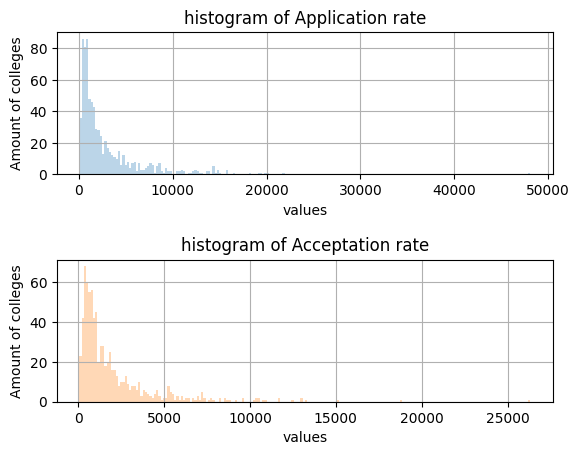

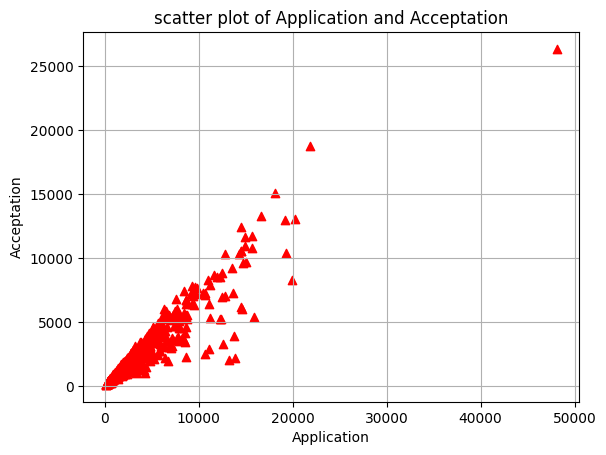

In [192]:
vis_tools.histogram(data_list=[college_data.columns['Apps'],college_data.columns['Accept']],
                    attr_list=['Application rate','Acceptation rate'])
vis_tools.scatter(college_data.columns['Apps'],college_data.columns['Accept'],
                  'Application','Acceptation')